In [44]:
import os, sys
import src
import numpy as np
import pandas as pd
from tqdm import tqdm
import scanpy as sc
import scvelo as scv

from importlib import reload
from src import _diffplot as dfp
from src import _configure, PATH
from scipy.sparse.csgraph import dijkstra

import matplotlib.pyplot as plt

sc.set_figure_params(figsize=(4, 4))

In [2]:
reload(src)
reload(dfp)

<module 'src._diffplot' from '/home/wergillius/Project/diffuse_differentiate/src/_diffplot.py'>

In [3]:
adata_diff = sc.read_h5ad(
    "/home/wergillius/Project/diffuse_differentiate/data/TFAtlas/GSE217460_210322_TFAtlas_differentiated.h5ad"
)

adata_filter = sc.read_h5ad(
    "/home/wergillius/Project/diffuse_differentiate/data/TFAtlas/TFAtlas_filtered_diff.h5ad"
)

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


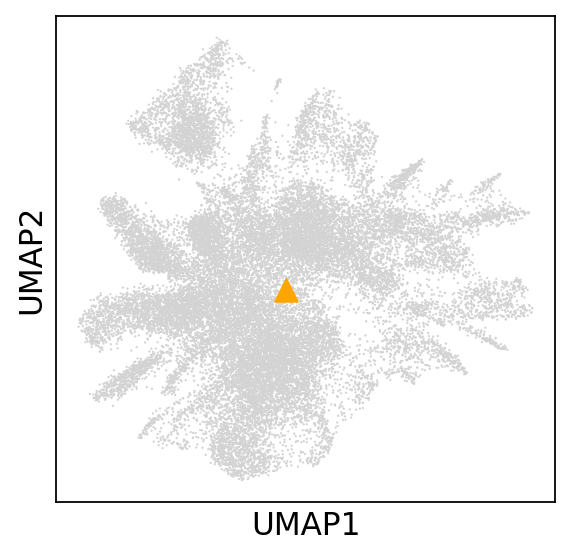

In [5]:
iroot = adata_diff.uns['iroot']
ax = sc.pl.umap(adata_diff, show=False)
ax.scatter(adata_diff.obsm['X_umap'][iroot,0], 
           adata_diff.obsm['X_umap'][iroot,1], marker='^', s=100,color='orange')

# find signature TFs for each cell-type

In [7]:
adata_diff.layers['a3_PathSampled_X'].shape

(28825, 4806)

In [181]:
TF_count = adata_diff.obs.TF.value_counts()
selected_TFs = TF_count[TF_count > 20].index

In [162]:
cell_type = adata_diff.obs['cell_type'].unique().tolist()

In [163]:
import pandas as pd

In [226]:
celltype_by_TF = pd.pivot_table(adata_diff.obs, index='cell_type', 
                                columns='TF', 
                                aggfunc={'louvain':"count"})
celltype_by_TF.columns = [col[1] for col in celltype_by_TF.columns]
celltype_by_TF = celltype_by_TF.reset_index(level=0).set_index('cell_type')

In [227]:
celltype_total_count = celltype_by_TF.sum(axis=1)

In [228]:
selected_celltype = celltype_total_count[celltype_total_count>20].index

In [229]:
selected_celltype

CategoricalIndex(['Astrocytes', 'Bronchiolar and alveolar epithelial cells',
                  'Ciliated epithelial cells', 'ENS neurons', 'Erythroblasts',
                  'Excitatory neurons', 'Ganglion cells',
                  'IGFBP1_DKK1 positive cells', 'Inhibitory neurons',
                  'Intestinal epithelial cells', 'Metanephric cells',
                  'PAEP_MECOM positive cells', 'Retinal pigment cells',
                  'Retinal progenitors and Muller glia',
                  'STC2_TLX1 positive cells', 'Smooth muscle cells',
                  'Squamous epithelial cells', 'Stromal cells',
                  'Syncytiotrophoblasts and villous cytotrophoblasts',
                  'Unipolar brush cells', 'Ureteric bud cells',
                  'Vascular endothelial cells'],
                 categories=['Astrocytes', 'Bronchiolar and alveolar epithelial cells', 'CCL19_CCL21 positive cells', 'Cardiomyocytes', 'Ciliated epithelial cells', 'ENS neurons', 'Endocardial cells',

In [239]:
selected_celltype = ["Inhibitory neurons",
 "Granule neurons",
 "ENS neurons",
 "Smooth muscle cells",
 "Vascular endothelial cells",
 "Stromal cells" ,
 'Ciliated epithelial cells',
 'Bronchiolar and alveolar epithelial cells',
#  "EMT smooth muscle",
 'STC2_TLX1 positive cells',
#  "GRHL squamouse epithelial",
 "Syncytiotrophoblasts and villous cytotrophoblasts",
 "Excitatory neurons",
#  "Squamous epithelial cells",
 "Erythroblasts"
]

In [240]:
celltype_by_TF = celltype_by_TF.loc[selected_celltype,selected_TFs]

TF_by_celltype = celltype_by_TF.T.divide(celltype_by_TF.T.values.sum(axis=1, keepdims=True),
                      axis=1
                      ).dropna()

In [241]:
thres = np.quantile(TF_by_celltype.values, [0.9], axis=0)

In [247]:
TF_by_celltype.to_csv("TF_diff_TFshortlistd.csv", index=True)

In [243]:
TF_by_celltype.columns

CategoricalIndex(['Inhibitory neurons', 'Granule neurons', 'ENS neurons',
                  'Smooth muscle cells', 'Vascular endothelial cells',
                  'Stromal cells', 'Ciliated epithelial cells',
                  'Bronchiolar and alveolar epithelial cells',
                  'STC2_TLX1 positive cells',
                  'Syncytiotrophoblasts and villous cytotrophoblasts',
                  'Excitatory neurons', 'Erythroblasts'],
                 categories=['Astrocytes', 'Bronchiolar and alveolar epithelial cells', 'CCL19_CCL21 positive cells', 'Cardiomyocytes', 'Ciliated epithelial cells', 'ENS neurons', 'Endocardial cells', 'Epicardial fat cells', ...], ordered=False, dtype='category', name='cell_type')

In [244]:
dfs = [TF_by_celltype.nlargest(4, columns=[col]) for col in TF_by_celltype.columns]
marker_TF_by_cell = pd.concat(dfs, axis=0)

In [245]:
import seaborn as sns

In [246]:
sns.set_theme(style='white', font_scale=0.9)
fig, ax = plt.subplots(1,1, figsize=(9,15), dpi=500)
sns.heatmap(marker_TF_by_cell, vmax=0.4, cmap='Reds', ax=ax)
ax.set_xlabel("")

Text(0.5, 962.2500000000002, '')

In [ ]:
marker_TF_by_cell

In [173]:
is_enriched = np.any(TF_by_celltype.values > thres, axis=1)

In [174]:
is_enriched.shape

(2515,)

In [175]:
TF_by_celltype[is_enriched]

cell_type,Bronchiolar and alveolar epithelial cells,Ciliated epithelial cells,ENS neurons,Erythroblasts,Inhibitory neurons,Intestinal epithelial cells,Metanephric cells,Retinal progenitors and Muller glia,STC2_TLX1 positive cells,Smooth muscle cells,Squamous epithelial cells,Stromal cells
TFORF0001-HIF3A,0.000000,0.333333,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000
TFORF0002-HIF3A,0.285714,0.142857,0.000000,0.000000,0.142857,0.000000,0.000000,0.000000,0.285714,0.142857,0.000000,0.000000
TFORF0003-HIF3A,0.000000,0.000000,0.000000,0.600000,0.000000,0.000000,0.000000,0.000000,0.200000,0.000000,0.000000,0.200000
TFORF0005-HIF3A,0.000000,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000
TFORF0007-TULP4,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000,0.000000,0.000000,0.250000,0.250000
...,...,...,...,...,...,...,...,...,...,...,...,...
TFORF3546-TSC22D3,0.000000,0.153846,0.076923,0.307692,0.000000,0.000000,0.000000,0.076923,0.076923,0.000000,0.307692,0.000000
TFORF3547-CBFB,0.090909,0.090909,0.000000,0.090909,0.090909,0.090909,0.090909,0.090909,0.000000,0.000000,0.272727,0.090909
TFORF3548-THAP10,0.000000,0.250000,0.000000,0.250000,0.125000,0.000000,0.000000,0.000000,0.000000,0.125000,0.250000,0.000000
TFORF3549-GFP,0.164179,0.134328,0.044776,0.029851,0.000000,0.000000,0.029851,0.029851,0.119403,0.179104,0.208955,0.059701


# Per gene linear regression

In [179]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import OneHotEncoder

In [ ]:
TFs = ['TFORF0391-FERD3L', 'TFORF1158-EOMES', 'TFORF0985-KLF4']
marker_genes = ["PAX6", "EPCAM", "VIM", "SOX17"]

In [104]:
TF_list =  np.stack([tf for i,tf in enumerate(adata_diff.obs.TF.unique())])

In [165]:
def get_x(adata_diff, gene_name="PSMC3"):
    TF_onehot = pd.get_dummies(adata_diff.obs.TF).values
    gene_X = adata_diff.X
    X =  np.concatenate([gene_X, TF_onehot], axis=1)

    gene_varid = np.where(adata_diff.var.index == gene_name)[0].item()
    Y = adata_diff.layers['a3_PathSampled_X'][:,gene_varid].copy()

    train_idx = adata_diff.obs.split != 'test'
    test_idx = adata_diff.obs.split == 'test'

    x_train = X[train_idx]
    x_test = X[test_idx]

    y_train = Y[train_idx]
    y_test = Y[test_idx]

    return x_train, x_test, y_train, y_test

In [ ]:
np.random.choice(adata_diff.var.index)

'PDE11A'

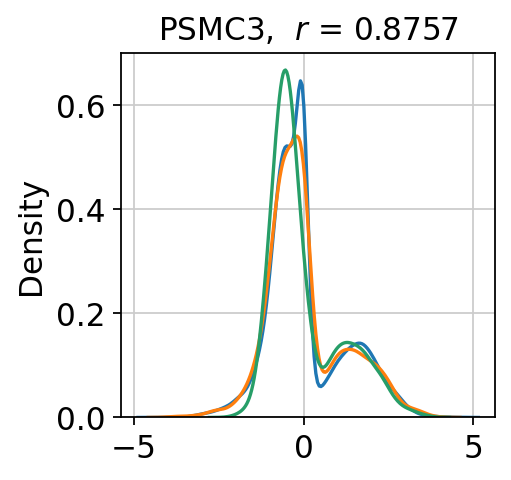

In [192]:
gene_name = "PSMC3"

x_train, x_test, y_train, y_test = get_x(adata_diff, gene_name=gene_name)

model = Ridge().fit(x_train,y_train)
y_pred = model.predict(x_test)
r = pearsonr(y_pred, y_test)[0]


fig, ax = plt.subplots(1,1, figsize=(3,3))
sns.kdeplot(y_train, ax=ax)
sns.kdeplot(y_test, ax=ax)
sns.kdeplot(y_pred, ax=ax)

# ax.text(0.3*ax.get_xlim()[1], 0.9*ax.get_ylim()[1], )
s = r",  $r$ = %.4f" %r

ax.set_title(gene_name + s)
fig.show()


# fit for all genes

In [194]:
TF_onehot = pd.get_dummies(adata_diff.obs.TF).values
gene_X = adata_diff.X
X =  np.concatenate([gene_X, TF_onehot], axis=1)

Y = adata_diff.layers['a3_PathSampled_X'].copy()

train_idx = adata_diff.obs.split != 'test'
test_idx = adata_diff.obs.split == 'test'

x_train = X[train_idx]
x_test = X[test_idx]

Y_train = Y[train_idx]
Y_test = Y[test_idx]

In [193]:
from tqdm.auto import tqdm

In [201]:
model.coef_.shape

(7341,)

In [203]:
model.get_params()

{'alpha': 1.0,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': None,
 'positive': False,
 'random_state': None,
 'solver': 'auto',
 'tol': 0.0001}

In [234]:
params

[-0.010586190968751907,
 0.001441821688786149,
 0.00047743183677084744,
 -0.009317392483353615,
 0.00470410892739892,
 0.004832874052226543,
 0.004712671507149935,
 -0.008467989973723888,
 -0.00621806550770998,
 -0.003286672756075859,
 0.00449635274708271,
 0.0011744537623599172,
 -0.0039515309035778046,
 0.00011553907097550109,
 -0.0002305152447661385,
 -0.00024171333643607795,
 -0.004966712091118097,
 0.002968971384689212,
 0.0029304560739547014,
 0.0005759285413660109,
 -0.002967419568449259,
 2.8318023396423087e-05,
 0.003193460637703538,
 -0.0005336526082828641,
 0.008960501290857792,
 -0.0031861199531704187,
 0.0002545755123719573,
 -0.0049559613689780235,
 0.0027149775996804237,
 0.006126739550381899,
 -0.004311705939471722,
 -0.0010785062331706285,
 0.0005197153077460825,
 -0.002955429721623659,
 0.00596202677115798,
 -0.0003872783563565463,
 0.0005771586438640952,
 -0.005514622200280428,
 -0.002610790776088834,
 -0.010625907219946384,
 0.0022791121155023575,
 0.000418421986978

In [212]:
from tqdm import tqdm

In [218]:
genes = np.random.choice(adata_diff.var.index,10)

In [224]:
model_dict = {}
params_dict = {}
r_dict = {}

for gene in tqdm(genes):

    gene_varid = np.where(adata_diff.var.index == gene)[0].item()

    y_train = Y_train[:,gene_varid]
    y_test = Y_test[:,gene_varid]

    model = Ridge().fit(x_train,y_train)
    y_pred = model.predict(x_test)
    r = pearsonr(y_pred, y_test)[0]

    model_dict[gene] = model
    r_dict[gene] = r
    params_dict[gene] = params

100%|██████████| 10/10 [00:28<00:00,  2.86s/it]


In [221]:
params_array = np.stack(params_dict.values())

In [236]:
params_array.shape

(10, 7342)

In [ ]:
np.save(params_array, 'ridgemodel_params.npy')

In [228]:
np.stack(r_dict.values()).reshape(-1,1)

array([[0.8470644 ],
       [0.78505735],
       [0.85757697],
       [0.88156692],
       [0.79417333],
       [0.92123079],
       [0.878783  ],
       [0.86539937],
       [0.88087317],
       [0.85903469]])

In [230]:
df = pd.DataFrame(np.stack(r_dict.values()), columns=['Pearson_r'], index=genes)

In [231]:
df

,Pearson_r
TRIM55,0.847064
LOC101926964,0.785057
PREX1,0.857577
LOC105374191,0.881567
PPP1R3C,0.794173
LOC105374418,0.921231
ABTB2,0.878783
CAPN13,0.865399
DIRC3,0.880873
LOC101928765,0.859035


In [245]:
'a2_PathSampled_X' in adata_diff.layers.keys()

True

In [246]:
adata_diff.layers['a3_PathSampled_X'].copy()

array([[-0.01304372, -0.03950553, -0.1273732 , ..., -0.02945027,
        -0.8200626 ,  1.2627907 ],
       [-0.00627327, -0.01899986, -0.06125915, ..., -0.01416387,
        -0.57002723,  1.4449041 ],
       [-0.02431566, -0.07364486, -1.6569475 , ..., -0.0549002 ,
        -0.8435171 ,  0.5304102 ],
       ...,
       [-0.00608842, -0.01844002, -2.4400148 , ..., -0.01374653,
        -0.07352486,  1.5898842 ],
       [-0.00248463, -0.00752522, -0.5295011 , ..., -0.00560984,
        -1.9982159 ,  0.67588264],
       [-0.03169942, -0.09600822, -0.30954835, ..., -0.07157144,
         1.169468  , -0.8204294 ]], dtype=float32)